# CNN Binary Classification Tutorial
Bu notebook adım adım basit bir CNN ile binary sınıflandırma gösterir: veri yükleme, ön işleme, model tasarımı, eğitim, kaydetme/yükleme, değerlendirme (accuracy, precision, recall, confusion matrix) ve Grad-CAM ısı haritası.
Kullanım: dataset'in `dataset_split/binary/train`, `.../val`, `.../test` şeklinde hazır olduğunu varsayar.

In [80]:
# 1) Importlar ve ayarlar
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Paths (çalışma dizinine göre ayarlayın)
BASE_DIR = Path('dataset_split') / 'binary'  # beklenen çıktı klasörü (dataset path)
# Results directory for all outputs produced by this notebook
RESULTS_DIR = Path('results') / 'binary'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

# 1) Veri yükleme: `image_dataset_from_directory` kullanarak train/val/test oluşturma
Bu yaklaşım klasör yapısını `class_name` olarak kullanır.

In [92]:
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

# Normalize class names if folder names changed: replace 'VS' with 'KR'
class_names = train_ds.class_names
class_names = [('KR' if c == 'VS' else c) for c in class_names]
print('Classes:', class_names)


Found 160 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Classes: ['KR', 'KV']


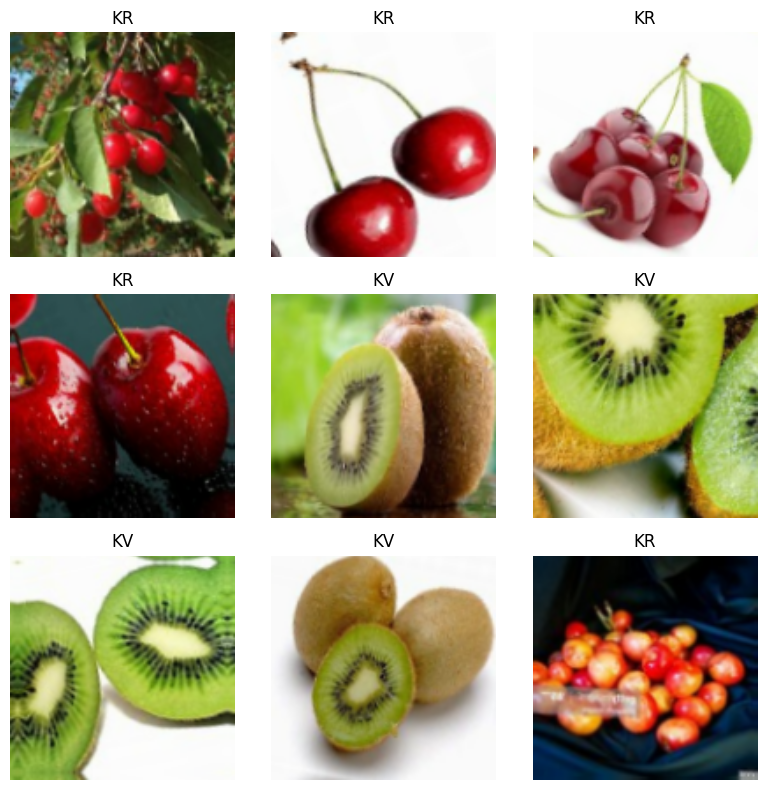

In [91]:
# 1.5) Veri örneklerini göster
import matplotlib.pyplot as plt
import numpy as np

def show_examples(dataset, class_names, num=9, rescale_to_uint8=True, interpolation='bilinear'):
    plt.figure(figsize=(8,8))
    for images, labels in dataset.take(1):
        # Convert to numpy and ensure correct dtype/range
        images = images.numpy()
        labels = labels.numpy()
        n = min(num, images.shape[0])
        for i in range(n):
            ax = plt.subplot(3,3,i+1)
            img = images[i]

            # Decide how to convert to uint8 for display:
            # - if float and max <= 1.5 -> assume [0,1] normalized, multiply by 255
            # - if float and max > 1.5 -> assume already [0,255]
            # - if integer type -> cast to uint8
            if rescale_to_uint8:
                if np.issubdtype(img.dtype, np.floating):
                    maxval = img.max()
                    if maxval <= 1.5:
                        img_show = np.clip(img * 255.0, 0, 255).astype('uint8')
                    else:
                        img_show = np.clip(img, 0, 255).astype('uint8')
                else:
                    img_show = img.astype('uint8')
            else:
                img_show = img

            # If single-channel, squeeze and use gray colormap
            if img_show.ndim == 3 and img_show.shape[-1] == 1:
                img_to_show = img_show.squeeze(-1)
                plt.imshow(img_to_show, cmap='gray', interpolation=interpolation)
            else:
                plt.imshow(img_show, interpolation=interpolation)
            plt.title(class_names[labels[i]])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Kullanım: eğitim setinden 9 örnek göster
show_examples(train_ds, class_names, num=9)

# 2) Ön işleme ve augmentation
- Normalize (0-1) ve data augmentation.

In [ ]:
normalization_layer = layers.Rescaling(1./255)  # [0,255] -> [0,1]
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds, training=False)
test_ds = prepare(test_ds, training=False)

# 3) CNN Modeli tasarımı
Yapay zeka modelimizi tanımladığımız ve oluşturduğumuz kısım.

In [84]:
def make_model(input_shape=(*IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu')(inputs)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.MaxPool2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # binary
    model = keras.Model(inputs, outputs)
    return model

model = make_model()
model.summary()

Model: "model_64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_12 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 28, 28, 128)       738

# 4) Compile ve eğitim
- Binary crossentropy.

In [85]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/20
5/5 [==============================] - 2s 95ms/step - loss: 0.6874 - accuracy: 0.5500 - val_loss: 0.6849 - val_accuracy: 0.6000
Epoch 2/20
5/5 [==============================] - 0s 48ms/step - loss: 0.6845 - accuracy: 0.5625 - val_loss: 0.6760 - val_accuracy: 0.6500
Epoch 3/20
5/5 [==============================] - 0s 49ms/step - loss: 0.6791 - accuracy: 0.5500 - val_loss: 0.6644 - val_accuracy: 0.6500
Epoch 4/20
5/5 [==============================] - 0s 47ms/step - loss: 0.6720 - accuracy: 0.5938 - val_loss: 0.6479 - val_accuracy: 0.8500
Epoch 5/20
5/5 [==============================] - 0s 48ms/step - loss: 0.6557 - accuracy: 0.7625 - val_loss: 0.6298 - val_accuracy: 0.7500
Epoch 6/20
5/5 [==============================] - 0s 49ms/step - loss: 0.6371 - accuracy: 0.8188 - val_loss: 0.5986 - val_accuracy: 0.7000
Epoch 7/20
5/5 [==============================] - 0s 69ms/step - loss: 0.6062 - accuracy: 0.8438 - val_loss: 0.5634 - val_accuracy: 0.7000
Epoch 8/20
5/5 [===========

# 5) Kaydetme ve Yükleme
- `model.save()` ile kaydetme ve `keras.models.load_model()` ile geri yükleme.

In [86]:
# Tam modeli kaydet
model.save(str(RESULTS_DIR / 'final_binary_model'))
# Yükleme örneği:
# loaded = keras.models.load_model(str(RESULTS_DIR / 'final_binary_model'))

INFO:tensorflow:Assets written to: results\binary\final_binary_model\assets


INFO:tensorflow:Assets written to: results\binary\final_binary_model\assets


# 6) Değerlendirme ve metrikler
- Test seti üzerinde tahmin, classification report ve confusion matrix.

Saved training plots to: results\binary\training_plots.png


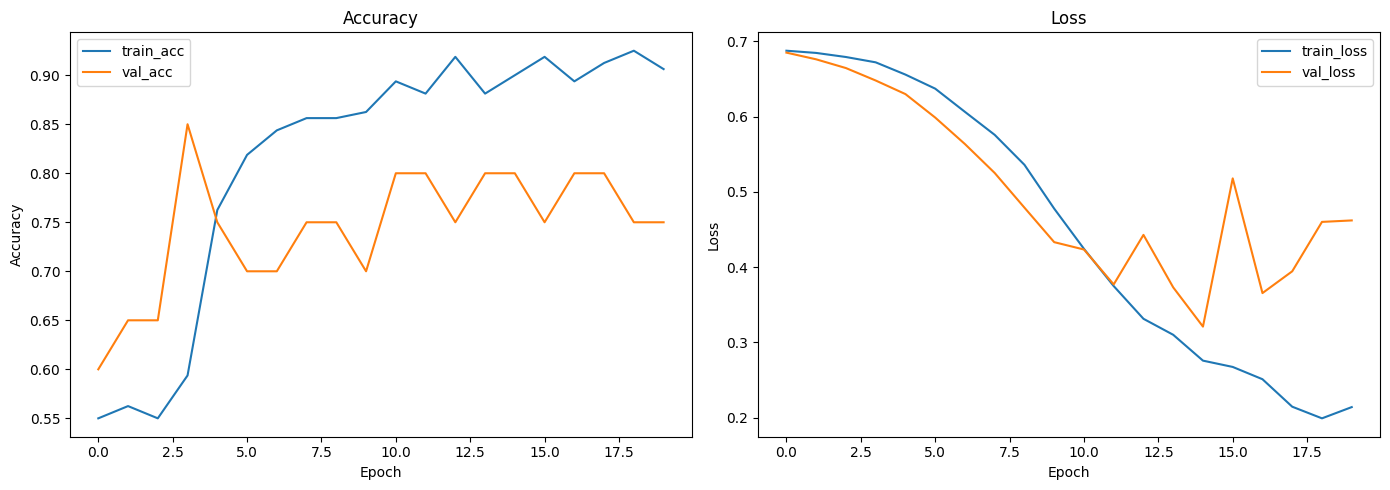

In [87]:
# Eğitim metrikleri: accuracy / val_accuracy ve loss / val_loss grafiklerini çiz ve kaydet
import matplotlib.pyplot as plt

# Ensure history exists
if 'history' in globals() and hasattr(history, 'history'):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(h.get('accuracy', []), label='train_acc')
    axes[0].plot(h.get('val_accuracy', []), label='val_acc')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(h.get('loss', []), label='train_loss')
    axes[1].plot(h.get('val_loss', []), label='val_loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plots_path = RESULTS_DIR / 'training_plots.png'
    plt.savefig(str(plots_path))
    print(f"Saved training plots to: {plots_path}")
    plt.show()
else:
    print('No `history` object found in the notebook namespace.')

1/1 [==============================] - 0s 93ms/step
              precision    recall  f1-score   support

          KR       0.83      1.00      0.91        10
          KV       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

Confusion matrix: [[10  0]
 [ 2  8]]


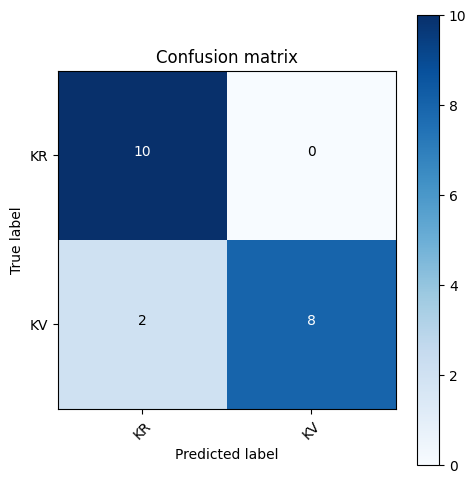

In [88]:
# Test üzerinde tahmin alma (tüm örnekleri tek bir array'a almak)
y_true = []
y_pred = []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch)
    preds = (preds.ravel() > 0.5).astype(int)
    y_true.extend(y_batch.numpy().tolist())
    y_pred.extend(preds.tolist())

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:', cm)

# Confusion matrix görselleştirme fonksiyonu
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(5,5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

plot_confusion_matrix(cm, class_names)